In [ ]:
# Import-Lib:

%matplotlib inline  
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ydata_profiling import ProfileReport

/Users/ayushbhagwate/Documents/Software/Vs-Code/ml-projects/wine_classification_pj4/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/ayushbhagwate/Documents/Software/Vs-Code/ml-projects/wine_classification_pj4/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [ ]:
#Load-Dataset:
df = pd.read_csv('../data/wine_classification.csv')
target = df['target']

In [ ]:
# Generating Profile_report:
profile = ProfileReport(df, explorative=True)
profile.to_file('../outputs/eda_reports.html')

print('EDA Report saved in outputs folder')

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 96.47it/s]

EDA Report saved in outputs folder


In [ ]:
# Basic-Info :
print(df.shape)
print(df.info())
print(df.describe())

(178, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64


In [ ]:
# Check-Missing-val:
missing_val = df.isnull().sum()
print('Missing_val: \n',missing_val)

# Check-Duplicate-val:
duplicate_val = df.duplicated().sum()
print('Duplicate_val:', duplicate_val)


Missing_val: 
 alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64
Duplicate_val: 0


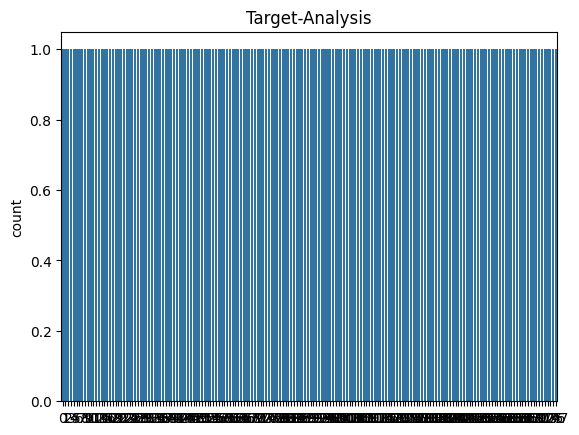

Imbalance-Check: target
1    71
0    59
2    48
Name: count, dtype: int64


In [ ]:
# Target-Analysis :
sns.countplot(df['target'])
plt.title('Target-Analysis')
plt.show()

# Checking the classes are balanced or not :
imb_check = df['target'].value_counts()
print('Imbalance-Check:',imb_check) # The clasess are imbalanced


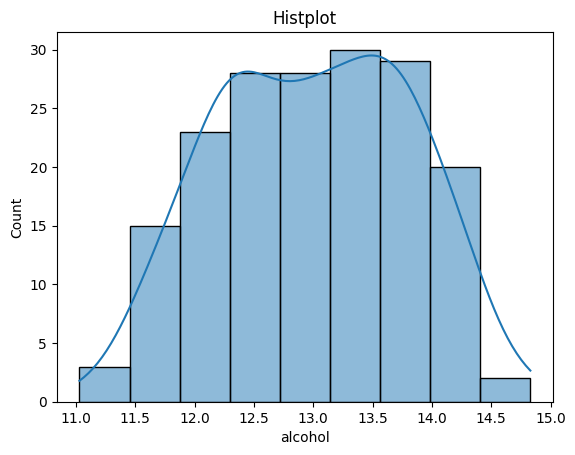

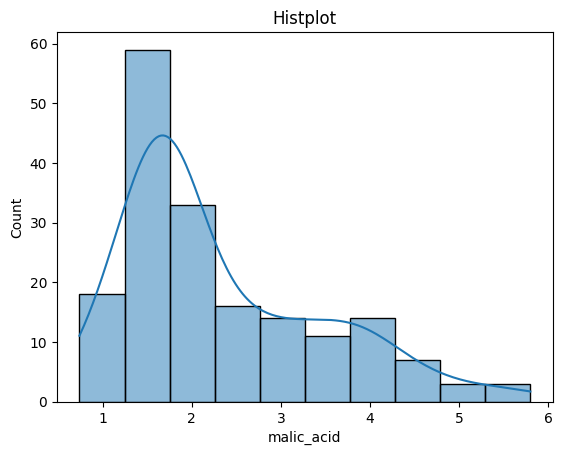

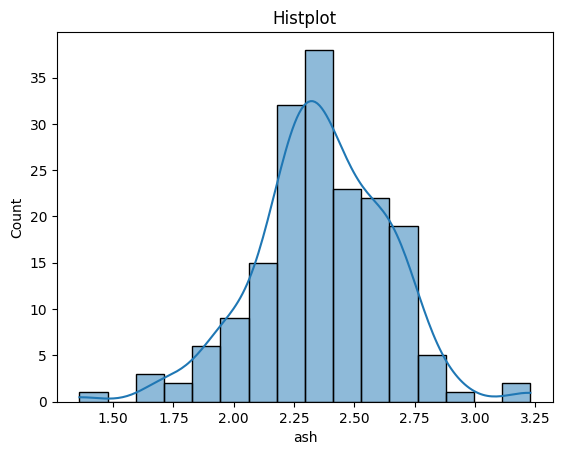

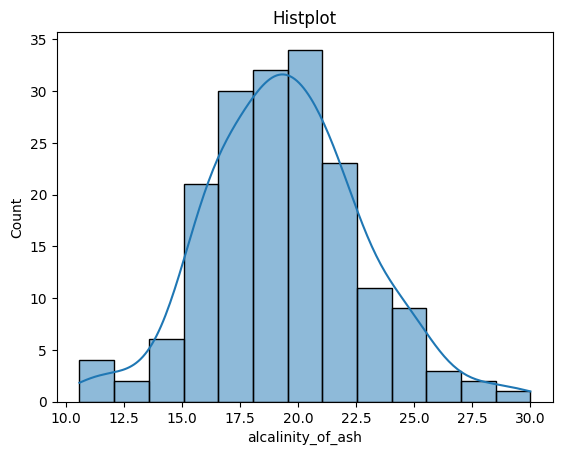

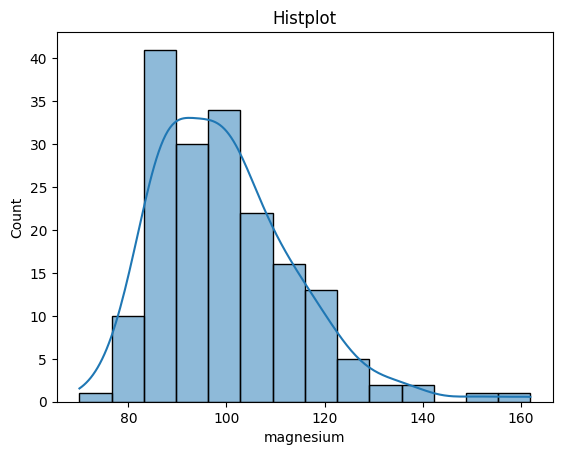

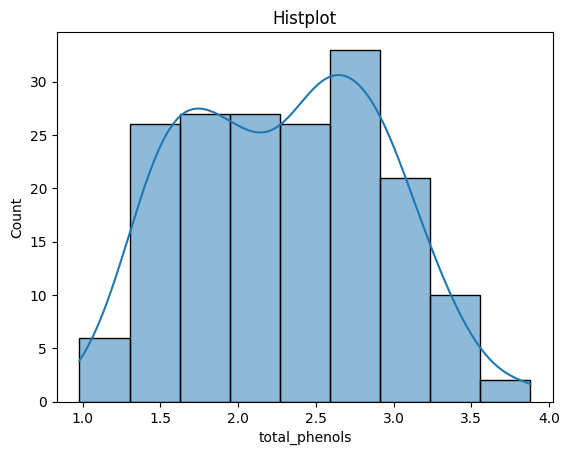

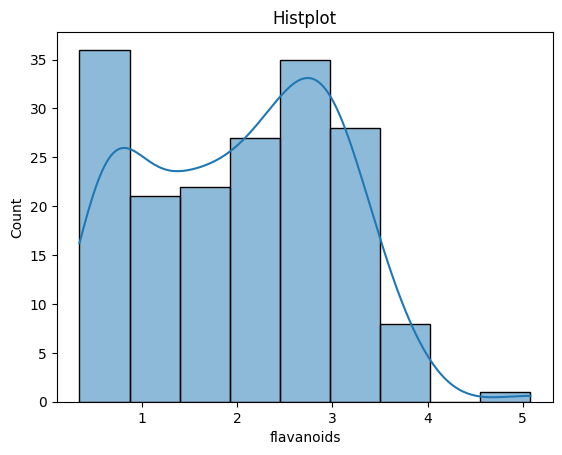

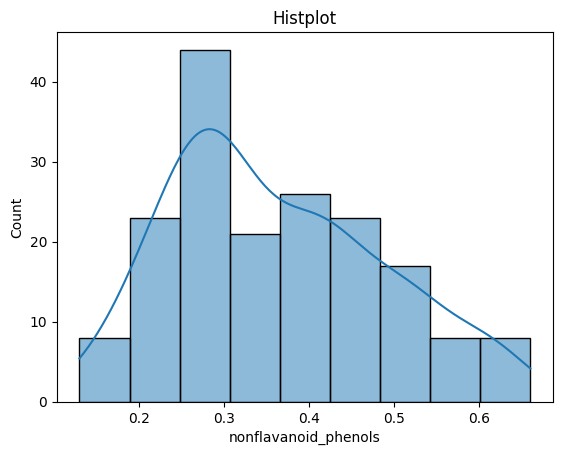

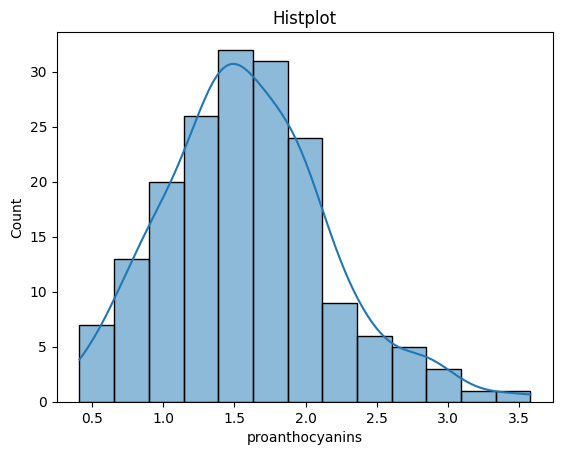

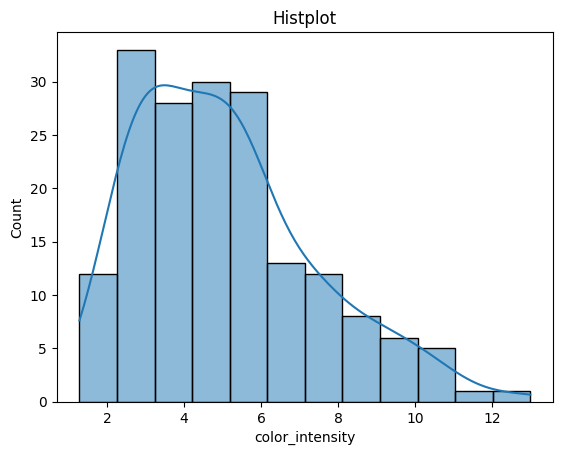

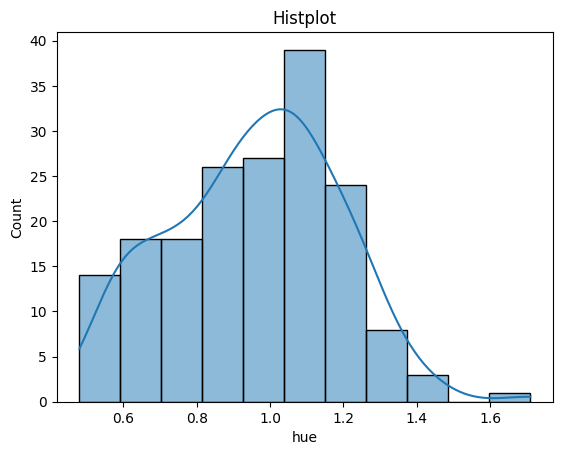

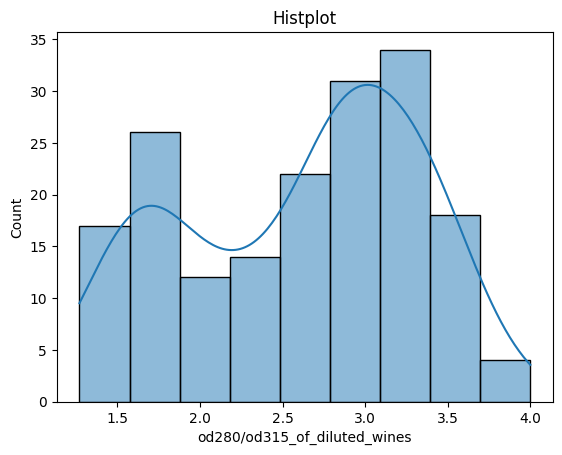

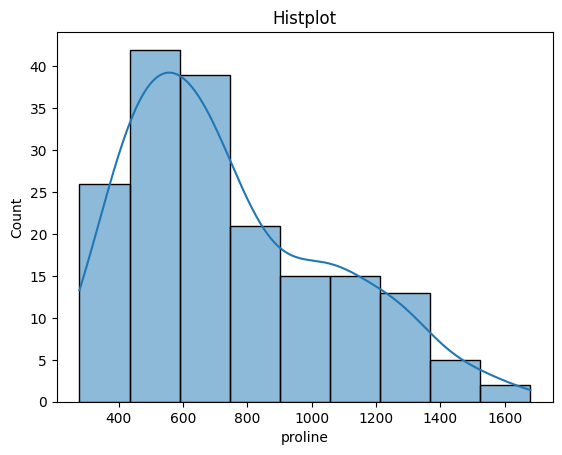

Skew_value:
 alcohol                        -0.051482
malic_acid                      1.039651
ash                            -0.176699
alcalinity_of_ash               0.213047
magnesium                       1.098191
total_phenols                   0.086639
flavanoids                      0.025344
nonflavanoid_phenols            0.450151
proanthocyanins                 0.517137
color_intensity                 0.868585
hue                             0.021091
od280/od315_of_diluted_wines   -0.307285
proline                         0.767822
target                          0.107431
dtype: float64


In [ ]:
# Numeric_features_only:
num_col = df.select_dtypes(include=['int64', 'float64']).columns

# Distribution of Data
for col in num_col[:-1]:
    sns.histplot(x=df[col], kde=True, data=df)
    plt.title('Histplot')
    plt.show()

# Checking_skew_values:
skew_val = df[num_col].skew()
print('Skew_value:\n', skew_val) # We have some Skew values, Fix them in the main-code


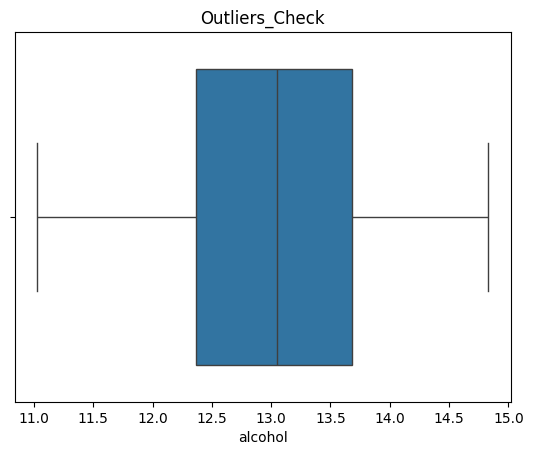

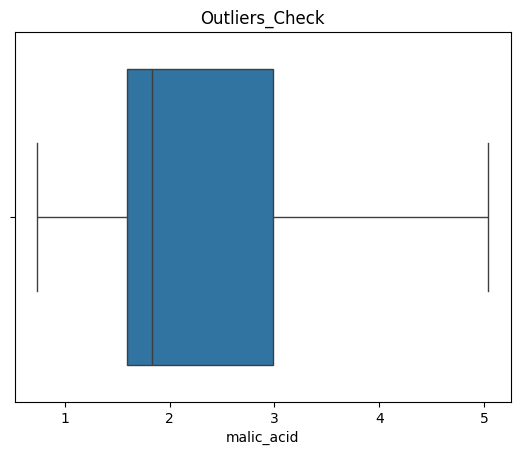

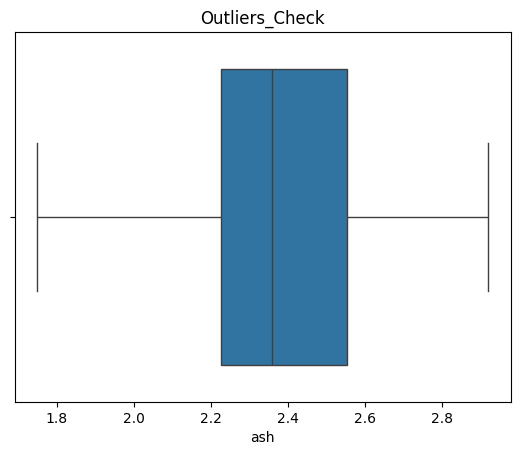

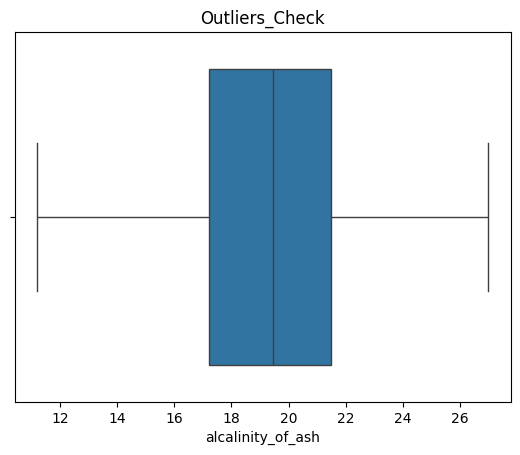

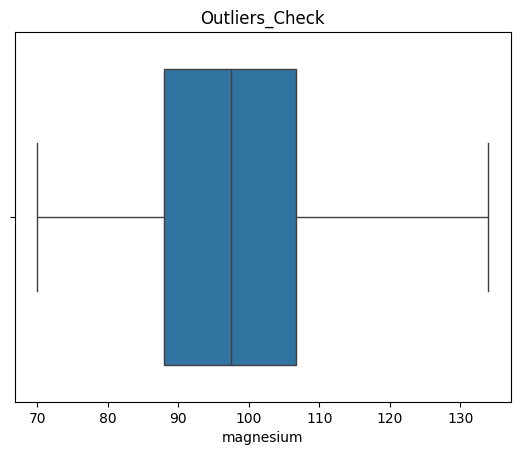

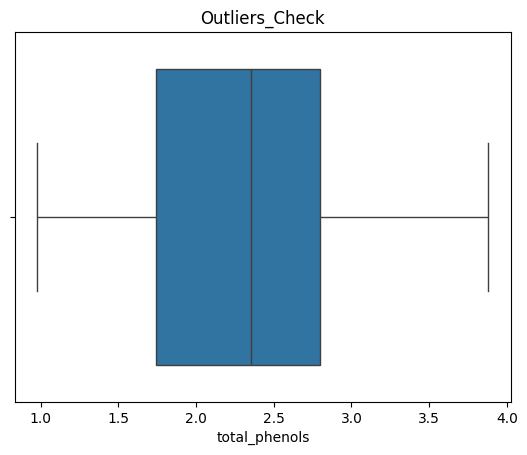

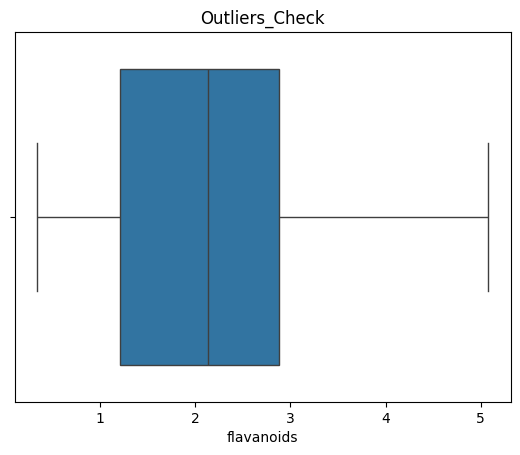

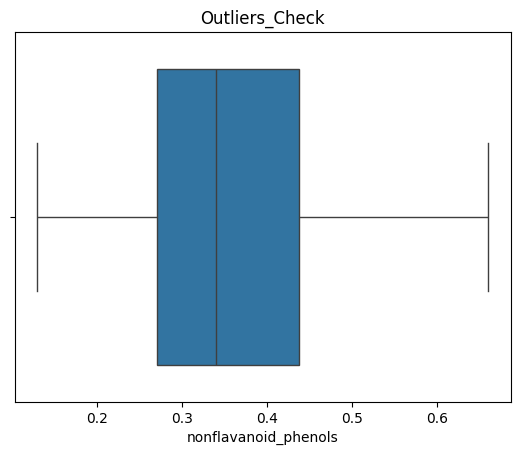

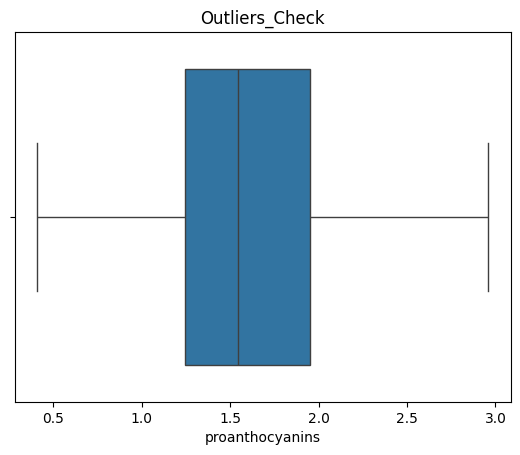

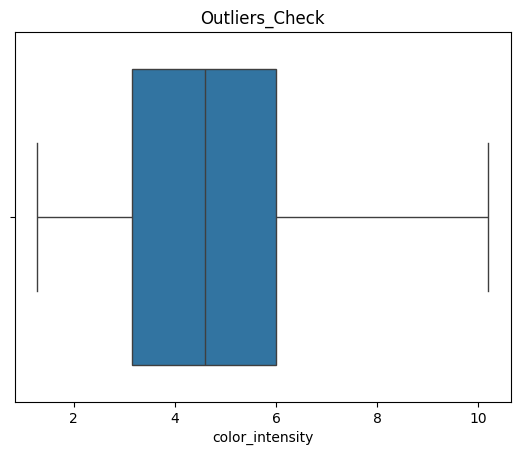

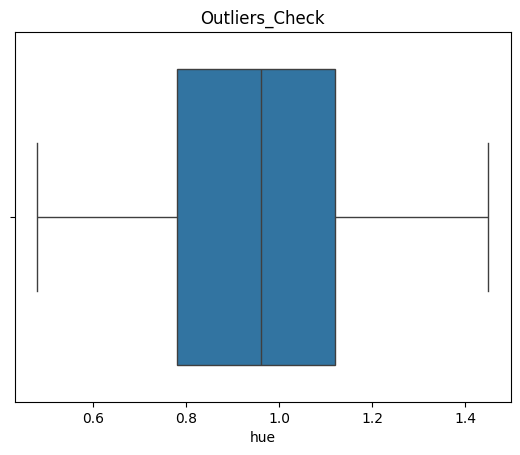

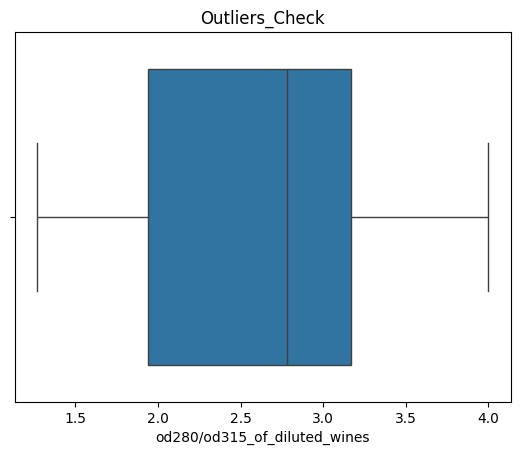

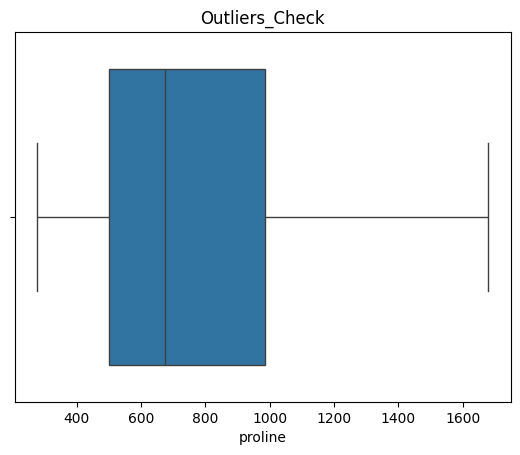

In [43]:
for col in num_col[:-1]:
    sns.boxplot(x=col, data=df)
    plt.title('Outliers_Check')
    plt.show()



In [49]:
# Removed Outliers:
for col in num_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1
 
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)] # This step removes the outliers.
    
    outliers = df[(df[col] < lower) | (df[col] > upper)] # This step checks whether any outliers still remain.
    print(len(outliers))



0
0
0
0
0
0
0
0
0
0
0
0
0
0


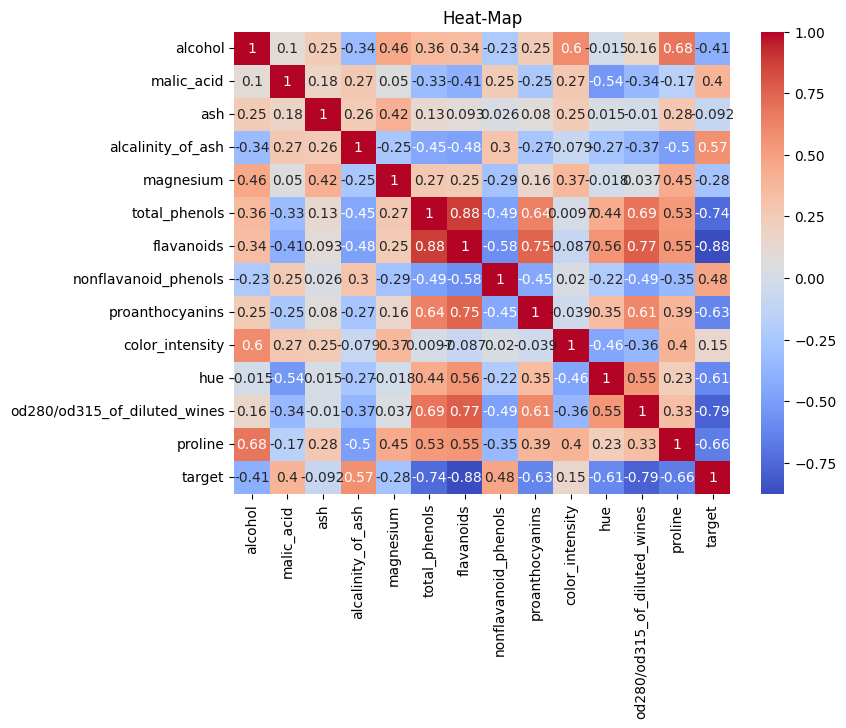

Important-Features : 
 flavanoids                      0.876642
od280/od315_of_diluted_wines    0.785232
total_phenols                   0.744427
proline                         0.659818
proanthocyanins                 0.626980
Name: target, dtype: float64


In [ ]:
# Correleation Analysis
corr = df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap='coolwarm',annot=True)
plt.title('Heat-Map')
plt.show()


#Important-Features:

target_corr = corr['target'].drop('target').abs().sort_values(ascending=False)
important_features_corr = target_corr[target_corr > 0.3]

print('Important-Features : \n',important_features_corr[:5])